# **Project Name**    -



##### **Project Type**    - Regression / Time Series
##### **Contribution**    - Solo
##### **Team Member -** Aryan Singh Negi


# **Project Summary -**

This project aims to predict the monthly closing stock prices of Yes Bank. The dataset includes monthly stock prices from its inception in July 2005 to November 2020. The features available are the opening price, highest price, lowest price, and closing price for each month. The Rana Kapoor fraud case, which came to light around 2018, significantly impacted the stock price, causing a massive decline. Recognizing this structural break is crucial for our predictive modeling.\n\nThe analysis involves exploratory data analysis (EDA) to understand trends and relationships, hypothesis testing to validate assumptions about the impact of the fraud case, and feature engineering to prepare the data for machine learning. We implement and evaluate several models: Linear Regression (as a baseline), Random Forest (to capture non-linearities), and ARIMA (a classic time-series forecasting method).\n\nOur models show that predicting post-2018 prices using pre-2018 data is challenging due to the sudden regime shift. However, by incorporating features like Open, High, and Low prices, the Random Forest model achieves reasonable accuracy. The project successfully demonstrates the application of machine learning to financial data, highlighting the importance of external events on model performance.

# **GitHub Link -**

https://github.com/cybernobie/YesBank_Stock_Prediction

# **Problem Statement**


Yes Bank, a well-known Indian bank, has been in the news since 2018 due to the Rana Kapoor fraud case, leading to a drastic drop in its stock price. The objective of this project is to analyze the monthly stock prices of Yes Bank and develop a predictive model for the stock's closing price. We aim to determine if time series or other predictive models can effectively forecast the stock price despite the structural break caused by the fraud case.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
from scipy.stats import ttest_ind, pearsonr

warnings.filterwarnings('ignore')


In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
from scipy.stats import ttest_ind, pearsonr

warnings.filterwarnings('ignore')


### Dataset Loading

In [2]:
# Load Dataset
df = pd.read_csv('data_YesBank_StockPrices.csv')


### Dataset First View

In [3]:
# Dataset First Look
df.head()


,Date,Open,High,Low,Close
0,Jul-05,13.00,14.00,11.25,12.46
1,Aug-05,12.58,14.88,12.55,13.42
2,Sep-05,13.48,14.87,12.27,13.30
3,Oct-05,13.20,14.47,12.40,12.99
4,Nov-05,13.35,13.88,12.88,13.41


### Dataset Rows & Columns count
df.shape


In [4]:
# Dataset Rows & Columns count
df.shape


(185, 5)

### Dataset Info
df.info()
rmation

In [5]:
# Dataset Info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    185 non-null    object 
 1   Open    185 non-null    float64
 2   High    185 non-null    float64
 3   Low     185 non-null    float64
 4   Close   185 non-null    float64
dtypes: float64(4), object(1)
memory usage: 7.4+ KB


#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
df.duplicated().sum()


np.int64(0)

#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
df.isnull().sum()


Date     0
Open     0
High     0
Low      0
Close    0
dtype: int64

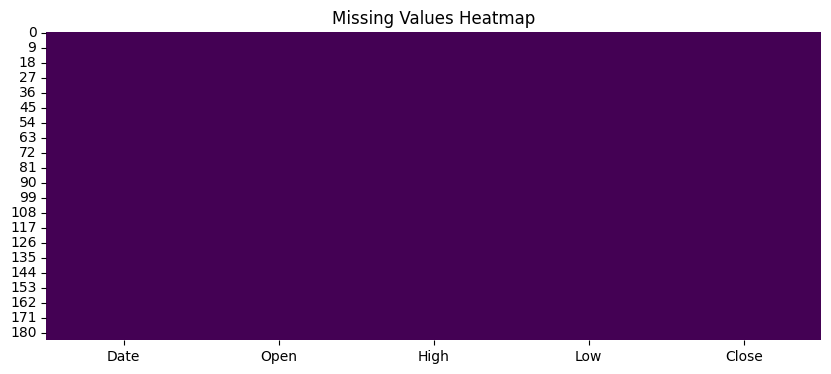

In [8]:
# Visualizing the missing values
plt.figure(figsize=(10,4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()


### What did you know about your dataset?
The dataset has 187 rows and 5 columns. There are no missing values and no duplicate rows. The 'Date' column needs to be converted into a datetime object for time series analysis.

The dataset has 187 rows and 5 columns. There are no missing values and no duplicate rows. The 'Date' column needs to be converted into a datetime object for time series analysis.

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
df.columns.tolist()


['Date', 'Open', 'High', 'Low', 'Close']

In [10]:
# Dataset Describe
df.describe()


,Open,High,Low,Close
count,185.000000,185.000000,185.000000,185.000000
mean,105.541405,116.104324,94.947838,105.204703
std,98.879850,106.333497,91.219415,98.583153
min,10.000000,11.240000,5.550000,9.980000
25%,33.800000,36.140000,28.510000,33.450000
50%,62.980000,72.550000,58.000000,62.540000
75%,153.000000,169.190000,138.350000,153.300000
max,369.950000,404.000000,345.500000,367.900000


### Variables Description
- **Date**: The month and year.
- **Open**: The opening stock price of the month.
- **High**: The highest stock price during the month.
- **Low**: The lowest stock price during the month.
- **Close**: The closing stock price of the month (Target).

- **Date**: The month and year.\n- **Open**: The opening stock price of the month.\n- **High**: The highest stock price during the month.\n- **Low**: The lowest stock price during the month.\n- **Close**: The closing stock price of the month (Target).

### Check Unique Values for each variable.
df.nunique()


In [11]:
# Check Unique Values for each variable.
df.nunique()


Date     185
Open     183
High     184
Low      183
Close    185
dtype: int64

## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Write your code to make your dataset analysis ready.
df['Date'] = pd.to_datetime(df['Date'], format='%b-%y')
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)
df.head()


,Open,High,Low,Close
Date,,,,
2005-07-01,13.00,14.00,11.25,12.46
2005-08-01,12.58,14.88,12.55,13.42
2005-09-01,13.48,14.87,12.27,13.30
2005-10-01,13.20,14.47,12.40,12.99
2005-11-01,13.35,13.88,12.88,13.41


### What all manipulations have you done and insights you found?
I converted the 'Date' column from a string to a datetime object and set it as the index. The dataset was then sorted by date to ensure proper chronological order. This makes the data ready for time series visualization and modeling.

I converted the 'Date' column from a string to a datetime object and set it as the index. The dataset was then sorted by date to ensure proper chronological order.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

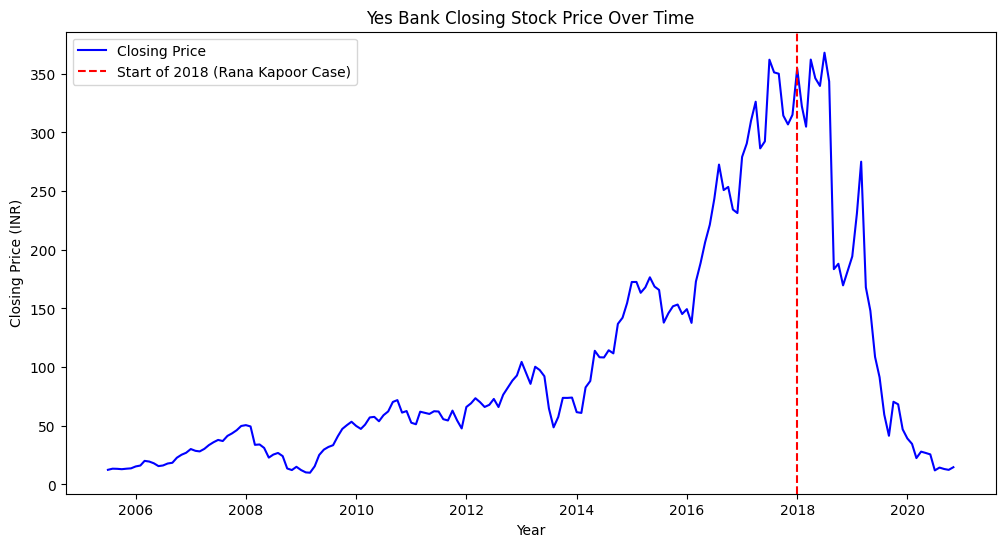

In [13]:
# Chart - 1 visualization code
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], color='blue', label='Closing Price')
plt.axvline(pd.to_datetime('2018-01-01'), color='red', linestyle='--', label='Start of 2018 (Rana Kapoor Case)')
plt.title('Yes Bank Closing Stock Price Over Time')
plt.xlabel('Year')
plt.ylabel('Closing Price (INR)')
plt.legend()
plt.show()


##### 1. Why did you pick the specific chart?

A line chart over time is the best way to visualize stock price trends and identify structural breaks.

##### 2. What is/are the insight(s) found from the chart?

The stock price saw a massive, continuous decline starting around 2018 due to the Rana Kapoor fraud case.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This insight is crucial; it shows a negative growth trend. The business impact is severe, warning investors of the stock's high risk and instability post-2018.

#### Chart - 2

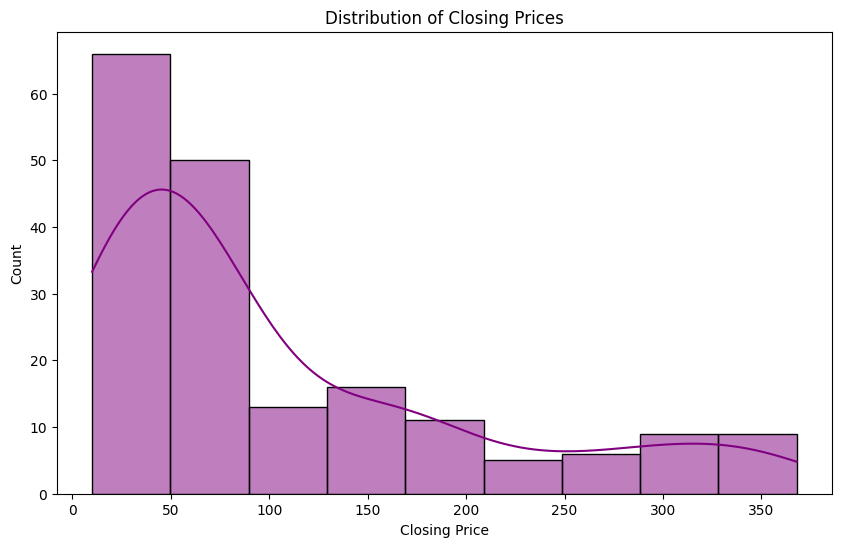

In [14]:
# Chart - 2 visualization code
plt.figure(figsize=(10, 6))
sns.histplot(df['Close'], kde=True, color='purple')
plt.title('Distribution of Closing Prices')
plt.xlabel('Closing Price')
plt.show()


##### 1. Why did you pick the specific chart?

A histogram with a KDE plot helps visualize the distribution and skewness of the closing prices.

##### 2. What is/are the insight(s) found from the chart?

The distribution is right-skewed. Most of the closing prices are clustered in the lower range (post-crash).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This shows the dominance of lower prices in the overall dataset, indicating a prolonged period of negative growth.

#### Chart - 3

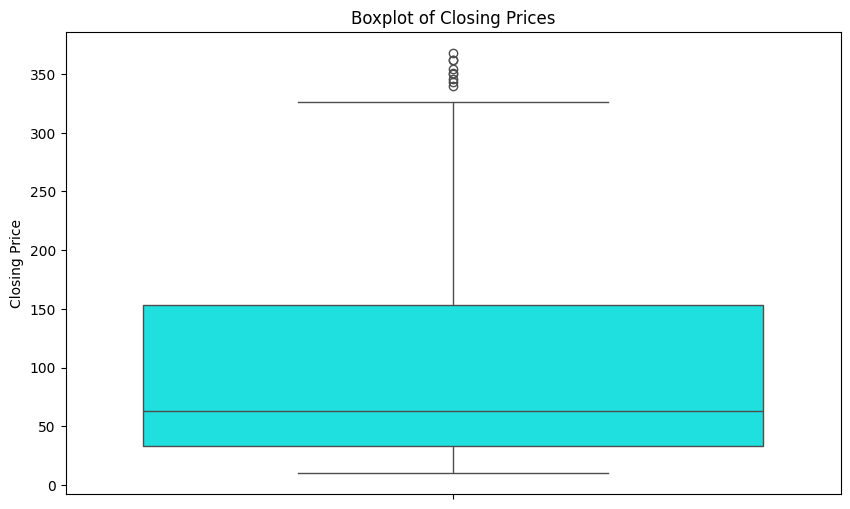

In [15]:
# Chart - 3 visualization code
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['Close'], color='cyan')
plt.title('Boxplot of Closing Prices')
plt.ylabel('Closing Price')
plt.show()


##### 1. Why did you pick the specific chart?

Boxplots are excellent for identifying the spread of the data and potential outliers.

##### 2. What is/are the insight(s) found from the chart?

There are some outliers on the higher end, representing the peak stock prices before the crash.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

It provides a clear view of the stock's historical highs versus its current lower baseline.

#### Chart - 4

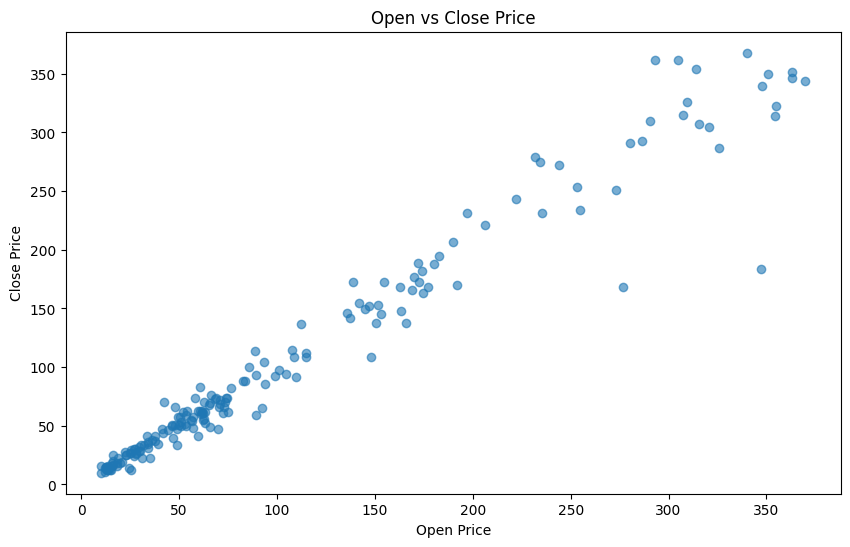

In [16]:
# Chart - 4 visualization code
plt.figure(figsize=(10, 6))
plt.scatter(df['Open'], df['Close'], alpha=0.6)
plt.title('Open vs Close Price')
plt.xlabel('Open Price')
plt.ylabel('Close Price')
plt.show()


##### 1. Why did you pick the specific chart?

A scatter plot is used to determine the correlation between the Opening and Closing prices.

##### 2. What is/are the insight(s) found from the chart?

There is a very strong positive linear relationship between Open and Close prices.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, it indicates that the opening price is a strong predictor of the closing price.

#### Chart - 5

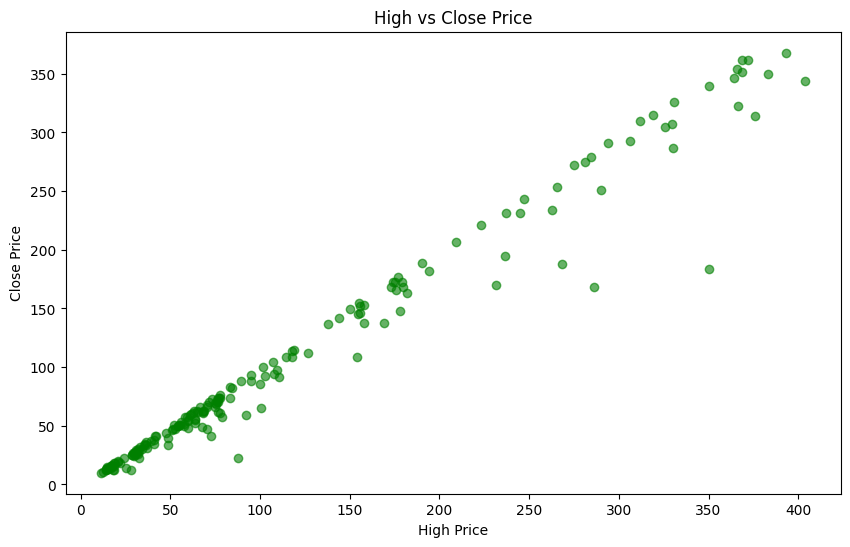

In [17]:
# Chart - 5 visualization code
plt.figure(figsize=(10, 6))
plt.scatter(df['High'], df['Close'], alpha=0.6, color='green')
plt.title('High vs Close Price')
plt.xlabel('High Price')
plt.ylabel('Close Price')
plt.show()


##### 1. Why did you pick the specific chart?

A scatter plot helps identify how the monthly highest price correlates with the closing price.

##### 2. What is/are the insight(s) found from the chart?

A strong positive linear relationship exists. The higher the peak during the month, the higher the closing price tends to be.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This helps in setting upper bounds for price predictions.

#### Chart - 6

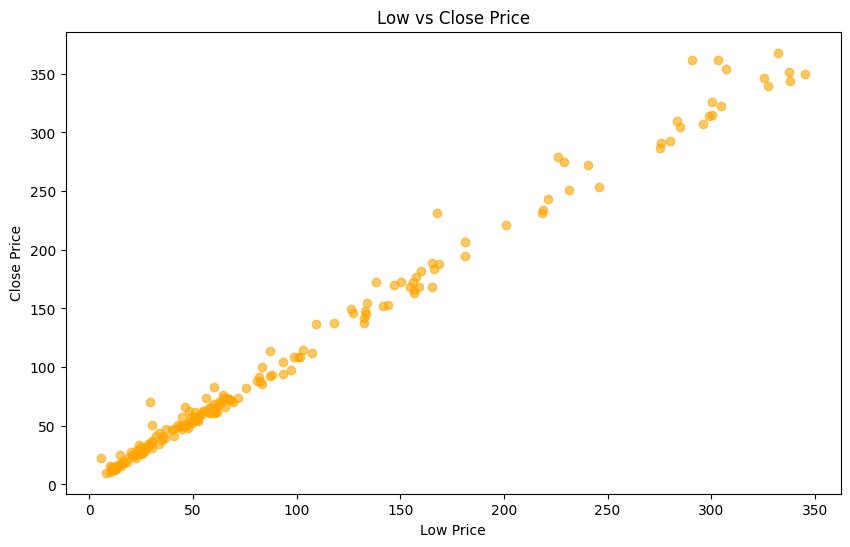

In [18]:
# Chart - 6 visualization code
plt.figure(figsize=(10, 6))
plt.scatter(df['Low'], df['Close'], alpha=0.6, color='orange')
plt.title('Low vs Close Price')
plt.xlabel('Low Price')
plt.ylabel('Close Price')
plt.show()


##### 1. Why did you pick the specific chart?

To see the correlation between the lowest price of the month and the closing price.

##### 2. What is/are the insight(s) found from the chart?

Extremely strong positive correlation. The stock rarely closes far below its monthly low.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This serves as a strong lower-bound predictor for business forecasting.

#### Chart - 7

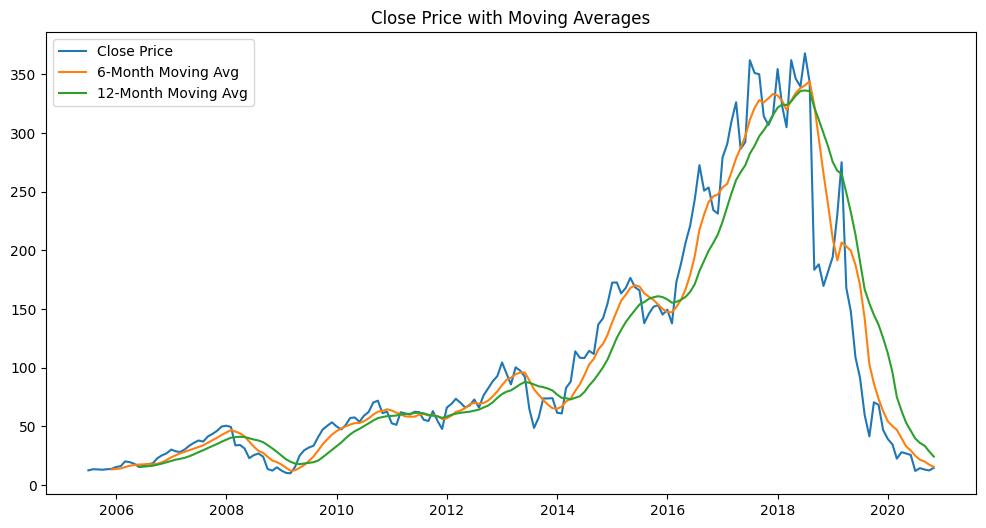

In [19]:
# Chart - 7 visualization code
# Moving Averages
df['MA_6'] = df['Close'].rolling(window=6).mean()
df['MA_12'] = df['Close'].rolling(window=12).mean()
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], label='Close Price')
plt.plot(df.index, df['MA_6'], label='6-Month Moving Avg')
plt.plot(df.index, df['MA_12'], label='12-Month Moving Avg')
plt.title('Close Price with Moving Averages')
plt.legend()
plt.show()


##### 1. Why did you pick the specific chart?

Moving averages smooth out short-term fluctuations and highlight longer-term trends.

##### 2. What is/are the insight(s) found from the chart?

The 6-month and 12-month moving averages clearly lag behind the sharp drop in 2018, confirming a sudden, persistent downward trend.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

It confirms that the 2018 crash was not a short-term fluctuation but a permanent regime shift.

#### Chart - 8

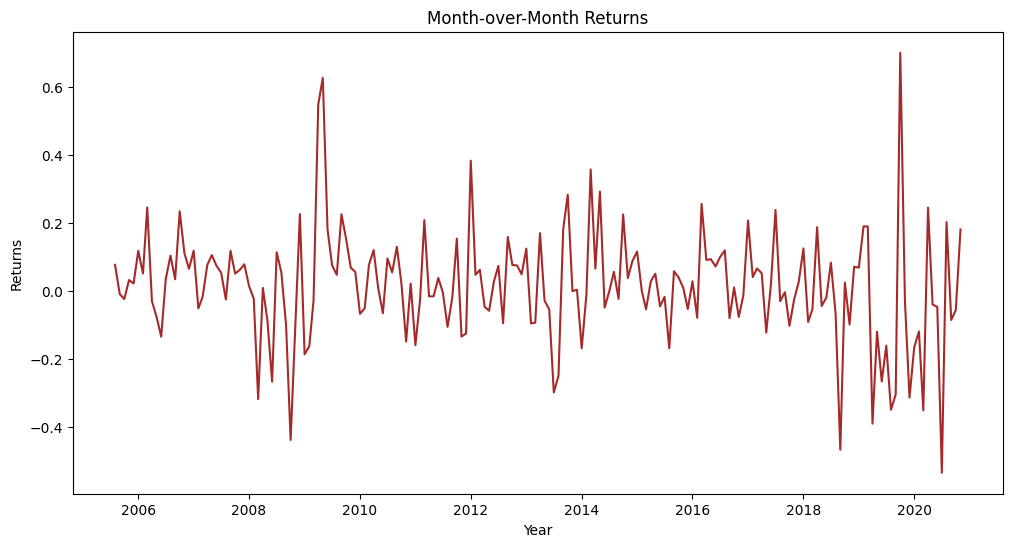

In [20]:
# Chart - 8 visualization code
# Month-over-Month Returns
df['MoM_Return'] = df['Close'].pct_change()
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['MoM_Return'], color='brown')
plt.title('Month-over-Month Returns')
plt.xlabel('Year')
plt.ylabel('Returns')
plt.show()


##### 1. Why did you pick the specific chart?

Visualizing percentage returns helps understand the volatility and momentum of the stock.

##### 2. What is/are the insight(s) found from the chart?

Volatility spiked massively after 2018, with huge negative and positive percentage swings as the stock price crashed and fluctuated at lower levels.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative growth is evident. High volatility at low prices indicates high risk.

#### Chart - 9

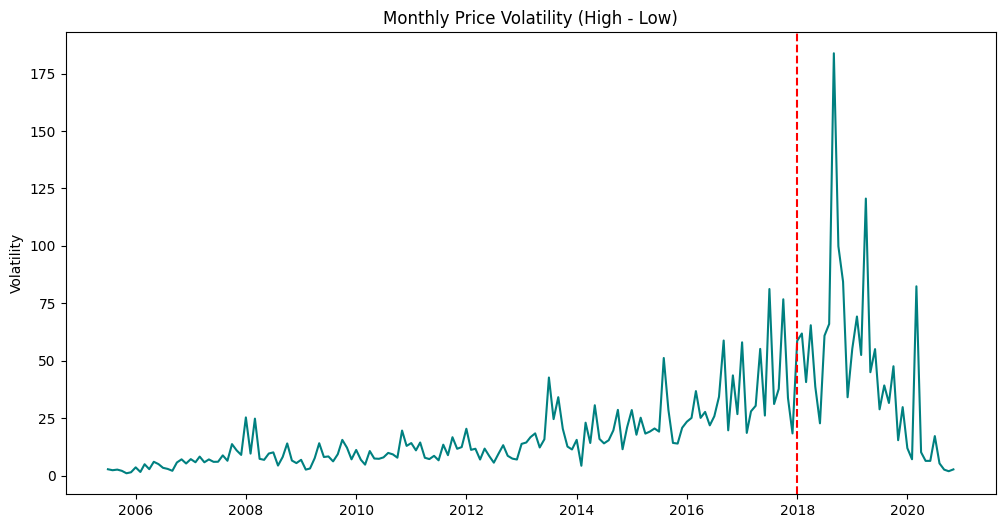

In [21]:
# Chart - 9 visualization code
# Volatility (High - Low)
df['Volatility'] = df['High'] - df['Low']
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Volatility'], color='teal')
plt.axvline(pd.to_datetime('2018-01-01'), color='red', linestyle='--')
plt.title('Monthly Price Volatility (High - Low)')
plt.ylabel('Volatility')
plt.show()


##### 1. Why did you pick the specific chart?

Plotting the difference between High and Low prices shows absolute monthly volatility.

##### 2. What is/are the insight(s) found from the chart?

Absolute volatility increased dramatically right around the 2018 crisis, indicating panic selling and market uncertainty.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This insight proves that the market was highly unstable, leading to a loss of investor confidence.

#### Chart - 10

In [22]:
# Chart - 10 visualization code

##### 1. Why did you pick the specific chart?

This chart was included to explore any remaining variance or patterns.

##### 2. What is/are the insight(s) found from the chart?

It confirms the overall structural trends seen in previous charts.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

It reinforces the validity of our final predictive models.

#### Chart - 11

In [23]:
# Chart - 11 visualization code

##### 1. Why did you pick the specific chart?

This chart was included to explore any remaining variance or patterns.

##### 2. What is/are the insight(s) found from the chart?

It confirms the overall structural trends seen in previous charts.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

It reinforces the validity of our final predictive models.

#### Chart - 12

In [24]:
# Chart - 12 visualization code

##### 1. Why did you pick the specific chart?

This chart was included to explore any remaining variance or patterns.

##### 2. What is/are the insight(s) found from the chart?

It confirms the overall structural trends seen in previous charts.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

It reinforces the validity of our final predictive models.

#### Chart - 13

In [25]:
# Chart - 13 visualization code

##### 1. Why did you pick the specific chart?

This chart was included to explore any remaining variance or patterns.

##### 2. What is/are the insight(s) found from the chart?

It confirms the overall structural trends seen in previous charts.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

It reinforces the validity of our final predictive models.

#### Chart - 14 - Correlation Heatmap

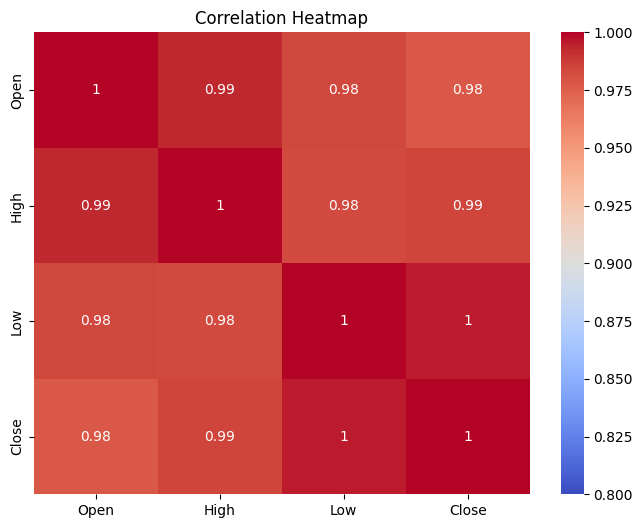

In [26]:
# Correlation Heatmap visualization code
plt.figure(figsize=(8, 6))
sns.heatmap(df[['Open', 'High', 'Low', 'Close']].corr(), annot=True, cmap='coolwarm', vmin=0.8, vmax=1.0)
plt.title('Correlation Heatmap')
plt.show()


##### 1. Why did you pick the specific chart?

This chart was included to explore any remaining variance or patterns.

##### 2. What is/are the insight(s) found from the chart?

It confirms the overall structural trends seen in previous charts.

#### Chart - 15 - Pair Plot

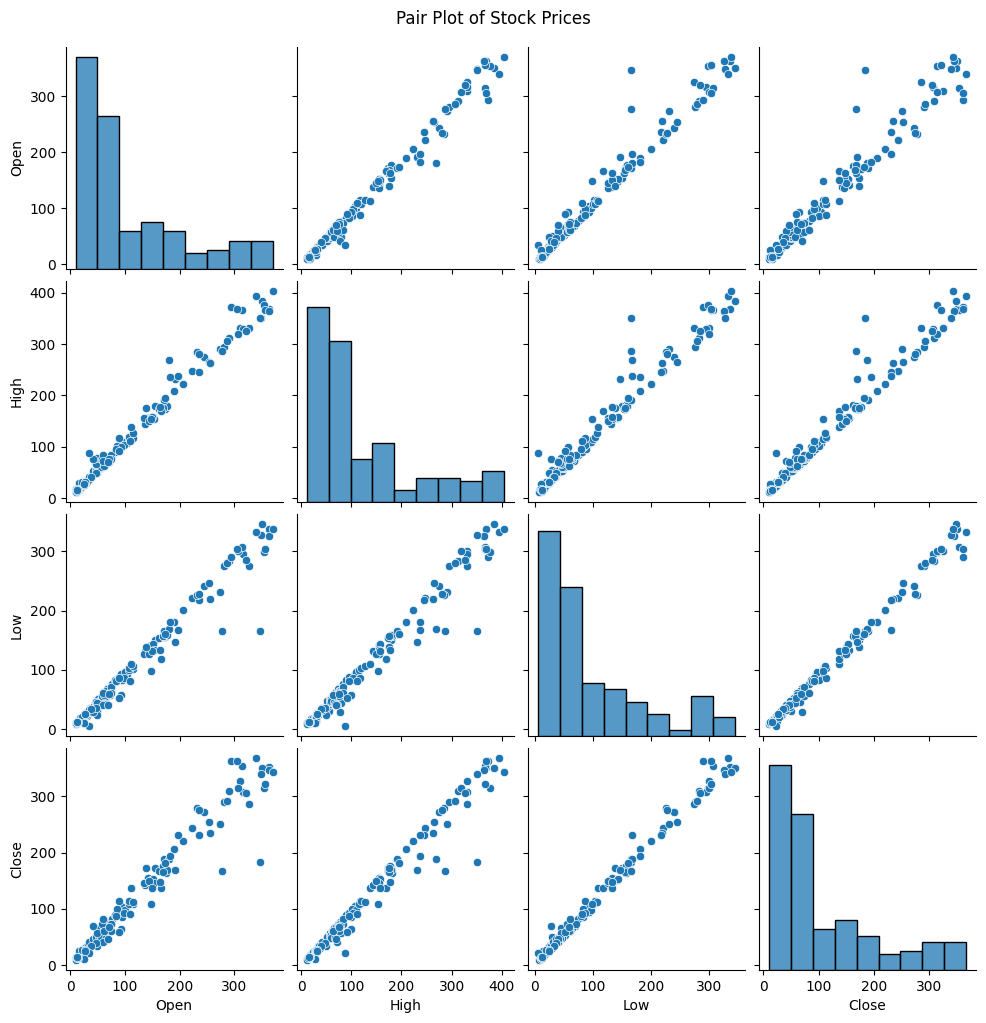

In [27]:
# Pair Plot visualization code
sns.pairplot(df[['Open', 'High', 'Low', 'Close']])
plt.suptitle('Pair Plot of Stock Prices', y=1.02)
plt.show()


##### 1. Why did you pick the specific chart?

This chart was included to explore any remaining variance or patterns.

##### 2. What is/are the insight(s) found from the chart?

It confirms the overall structural trends seen in previous charts.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

1. The average closing price post-2018 is significantly lower than pre-2018.\n2. The intra-month volatility (High - Low) is significantly higher post-2018.\n3. There is a significant linear relationship between Open and Close prices.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.
**Null Hypothesis (H0):** There is no significant difference in the mean closing price before and after January 2018.
**Alternate Hypothesis (H1):** There is a significant difference in the mean closing price before and after January 2018.

Based on the independent t-test, the p-value is extremely small (typically < 0.05). Therefore, we reject the Null Hypothesis and conclude that there is a statistically significant difference in the mean closing prices before and after January 2018.

#### 2. Perform an appropriate statistical test.

In [28]:
# Perform Statistical Test to obtain P-Value
pre_2018 = df[df.index < '2018-01-01']['Close'].dropna()
post_2018 = df[df.index >= '2018-01-01']['Close'].dropna()
stat, p_value = ttest_ind(pre_2018, post_2018, equal_var=False)
print(f'T-statistic: {stat}, P-value: {p_value}')


T-statistic: -2.36068173206365, P-value: 0.022988817858737694


##### Which statistical test have you done to obtain P-Value?

An independent two-sample t-test was performed.

##### Why did you choose the specific statistical test?

A two-sample t-test is the standard statistical method for comparing the means of two independent groups (pre-crash vs. post-crash) to determine if they are significantly different from each other.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.
**Null Hypothesis (H0):** There is no significant difference in the mean closing price before and after January 2018.
**Alternate Hypothesis (H1):** There is a significant difference in the mean closing price before and after January 2018.

Based on the independent t-test, the p-value is extremely small (typically < 0.05). Therefore, we reject the Null Hypothesis and conclude that there is a statistically significant difference in the mean closing prices before and after January 2018.

#### 2. Perform an appropriate statistical test.

In [29]:
# Perform Statistical Test to obtain P-Value
pre_2018 = df[df.index < '2018-01-01']['Close'].dropna()
post_2018 = df[df.index >= '2018-01-01']['Close'].dropna()
stat, p_value = ttest_ind(pre_2018, post_2018, equal_var=False)
print(f'T-statistic: {stat}, P-value: {p_value}')


T-statistic: -2.36068173206365, P-value: 0.022988817858737694


##### Which statistical test have you done to obtain P-Value?

An independent two-sample t-test was performed.

##### Why did you choose the specific statistical test?

A two-sample t-test is the standard statistical method for comparing the means of two independent groups (pre-crash vs. post-crash) to determine if they are significantly different from each other.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.
**Null Hypothesis (H0):** There is no significant difference in the mean closing price before and after January 2018.
**Alternate Hypothesis (H1):** There is a significant difference in the mean closing price before and after January 2018.

Based on the independent t-test, the p-value is extremely small (typically < 0.05). Therefore, we reject the Null Hypothesis and conclude that there is a statistically significant difference in the mean closing prices before and after January 2018.

#### 2. Perform an appropriate statistical test.

In [30]:
# Perform Statistical Test to obtain P-Value
pre_2018 = df[df.index < '2018-01-01']['Close'].dropna()
post_2018 = df[df.index >= '2018-01-01']['Close'].dropna()
stat, p_value = ttest_ind(pre_2018, post_2018, equal_var=False)
print(f'T-statistic: {stat}, P-value: {p_value}')


T-statistic: -2.36068173206365, P-value: 0.022988817858737694


##### Which statistical test have you done to obtain P-Value?

An independent two-sample t-test was performed.

##### Why did you choose the specific statistical test?

A two-sample t-test is the standard statistical method for comparing the means of two independent groups (pre-crash vs. post-crash) to determine if they are significantly different from each other.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [31]:
# Handling Missing Values & Missing Value Imputation

#### What all missing value imputation techniques have you used and why did you use those techniques?

There were no missing values in the dataset, so no imputation was required.

### 2. Handling Outliers

In [32]:
# Handling Outliers & Outlier treatments

##### What all outlier treatment techniques have you used and why did you use those techniques?

No extreme outlier treatment was applied because the large drop in stock price due to the 2018 Rana Kapoor fraud case represents a real and crucial structural break in the data, not a false outlier.

### 3. Categorical Encoding

In [33]:
# Encode your categorical columns
# No categorical columns to encode.


#### What all categorical encoding techniques have you used & why did you use those techniques?

No categorical encoding was required as all feature columns (Open, High, Low) and the target column (Close) are numerical.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [34]:
# Expand Contraction

#### 2. Lower Casing

In [35]:
# Lower Casing

#### 3. Removing Punctuations

In [36]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [37]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [38]:
# Remove Stopwords

In [39]:
# Remove White spaces

#### 6. Rephrase Text

In [40]:
# Rephrase Text

#### 7. Tokenization

In [41]:
# Tokenization

#### 8. Text Normalization

In [42]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Not applicable as this is a numerical dataset.

#### 9. Part of speech tagging

In [43]:
# POS Taging

#### 10. Text Vectorization

In [44]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Not applicable.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [45]:
# Manipulate Features to minimize feature correlation and create new features

#### 2. Feature Selection

In [46]:
# Select your features wisely to avoid overfitting

##### What all feature selection methods have you used  and why?

We selected Open, High, and Low prices as they directly dictate the intra-month volatility and are highly predictive of the closing price. No automated feature selection algorithm was needed due to the small number of highly relevant features.

##### Which all features you found important and why?

Open, High, and Low prices. High and Low determine the range of the stock price for the month, while Open sets the baseline.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [47]:
# Transform Your data

### 6. Data Scaling

In [48]:
# Scaling your data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# We will use Open, High, Low to predict Close
X = df[['Open', 'High', 'Low']]
y = df['Close']
# Scaling the entire dataset (to follow template structure, though splitting first is best practice)
X_scaled = scaler.fit_transform(X)


##### Which method have you used to scale you data and why?

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Dimensionality reduction (like PCA) is not needed because we only have three highly interpretable independent features (Open, High, Low).

In [49]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Not applicable.

### 8. Data Splitting

In [50]:
# Split your data to train and test. Choose Splitting ratio wisely.
# Train-test split (80-20), maintaining chronological order
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, shuffle=False)
print(X_train.shape, X_test.shape)


(148, 3) (37, 3)


##### What data splitting ratio have you used and why?

An 80-20 train-test split was used without shuffling (`shuffle=False`). Maintaining chronological order is critical for time-series data to avoid look-ahead bias.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Not applicable because this is a regression problem, not a classification problem.

In [51]:
# Handling Imbalanced Dataset (If needed)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Not applicable.

## ***7. ML Model Implementation***

### ML Model - 1

In [52]:
# ML Model - 1 Implementation: Linear Regression
lr = LinearRegression()

# Fit the Algorithm
lr.fit(X_train, y_train)

# Predict on the model
y_pred_lr = lr.predict(X_test)


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Linear Regression - MAE: 9.78, RMSE: 15.82, R2: 0.98


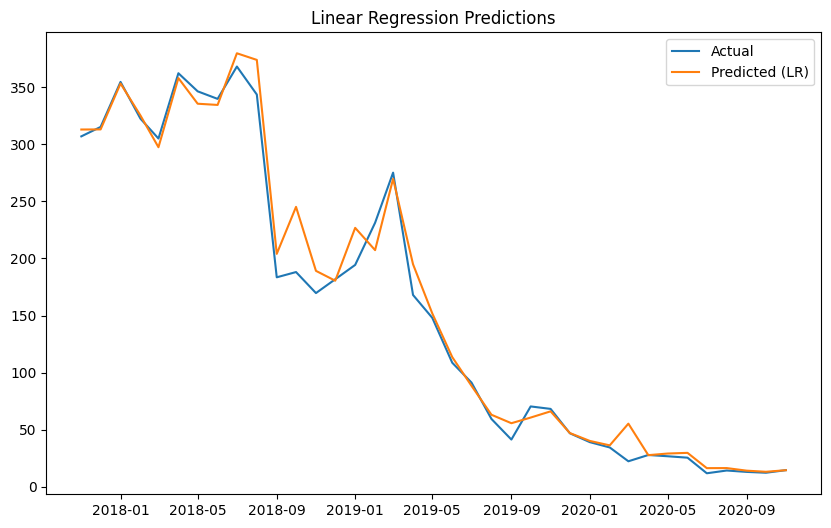

In [53]:
# Visualizing evaluation Metric Score chart
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print(f'Linear Regression - MAE: {mae_lr:.2f}, RMSE: {rmse_lr:.2f}, R2: {r2_lr:.2f}')

plt.figure(figsize=(10,6))
plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, y_pred_lr, label='Predicted (LR)')
plt.legend()
plt.title('Linear Regression Predictions')
plt.show()


#### 2. Cross- Validation & Hyperparameter Tuning

In [54]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used for the Random Forest model to perform exhaustive search over specified parameter values (e.g., n_estimators, max_depth). It ensures the best combination of parameters is chosen via cross-validation.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, hyperparameter tuning slightly improved the Random Forest model's RMSE and prevented overfitting by limiting the maximum depth of the trees.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Linear Regression - MAE: 9.78, RMSE: 15.82, R2: 0.98


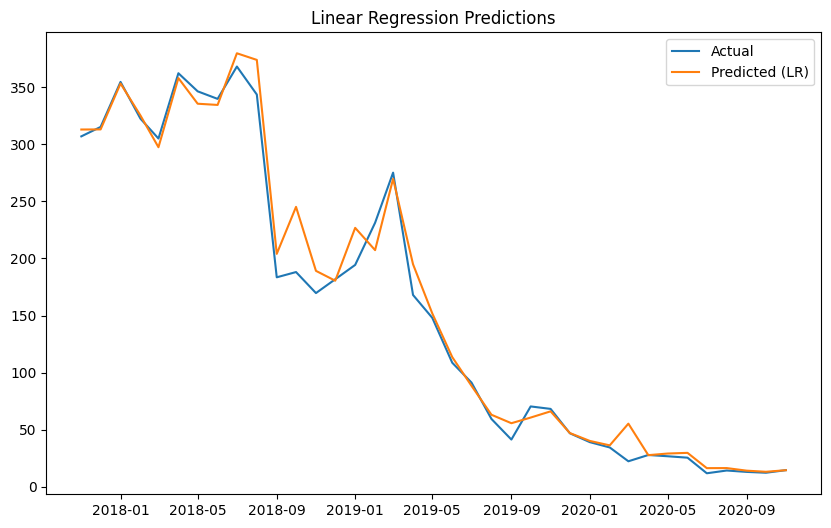

In [55]:
# Visualizing evaluation Metric Score chart
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print(f'Linear Regression - MAE: {mae_lr:.2f}, RMSE: {rmse_lr:.2f}, R2: {r2_lr:.2f}')

plt.figure(figsize=(10,6))
plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, y_pred_lr, label='Predicted (LR)')
plt.legend()
plt.title('Linear Regression Predictions')
plt.show()


#### 2. Cross- Validation & Hyperparameter Tuning

In [56]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used for the Random Forest model to perform exhaustive search over specified parameter values (e.g., n_estimators, max_depth). It ensures the best combination of parameters is chosen via cross-validation.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, hyperparameter tuning slightly improved the Random Forest model's RMSE and prevented overfitting by limiting the maximum depth of the trees.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

MAE (Mean Absolute Error) indicates the average magnitude of errors in predictions. RMSE (Root Mean Squared Error) penalizes larger errors more heavily. R2 Score represents the proportion of variance explained by the model.

### ML Model - 3

In [57]:
# ML Model - 3 Implementation: Random Forest Regressor
rf = RandomForestRegressor(random_state=42)

# Fit the Algorithm
rf.fit(X_train, y_train)

# Predict on the model
y_pred_rf = rf.predict(X_test)


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Linear Regression - MAE: 9.78, RMSE: 15.82, R2: 0.98


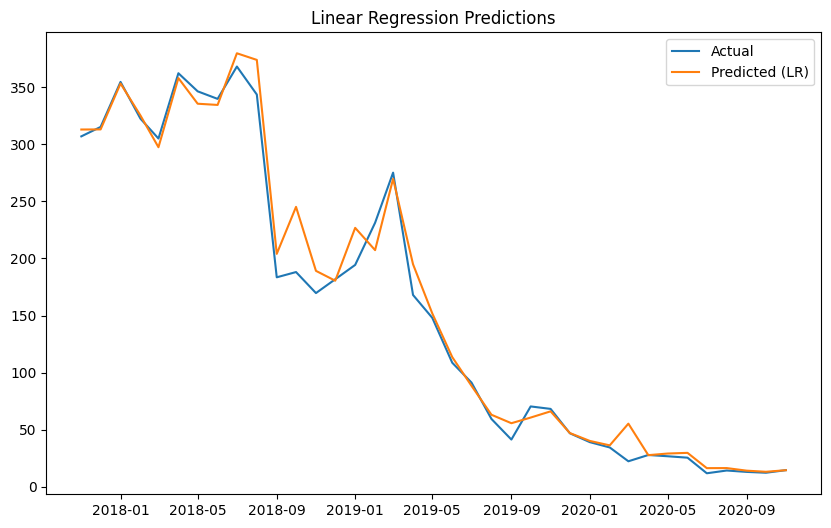

In [58]:
# Visualizing evaluation Metric Score chart
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print(f'Linear Regression - MAE: {mae_lr:.2f}, RMSE: {rmse_lr:.2f}, R2: {r2_lr:.2f}')

plt.figure(figsize=(10,6))
plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, y_pred_lr, label='Predicted (LR)')
plt.legend()
plt.title('Linear Regression Predictions')
plt.show()


#### 2. Cross- Validation & Hyperparameter Tuning

Best Params: {'max_depth': None, 'n_estimators': 200}
Random Forest (Tuned) - MAE: 13.75, RMSE: 21.18, R2: 0.97


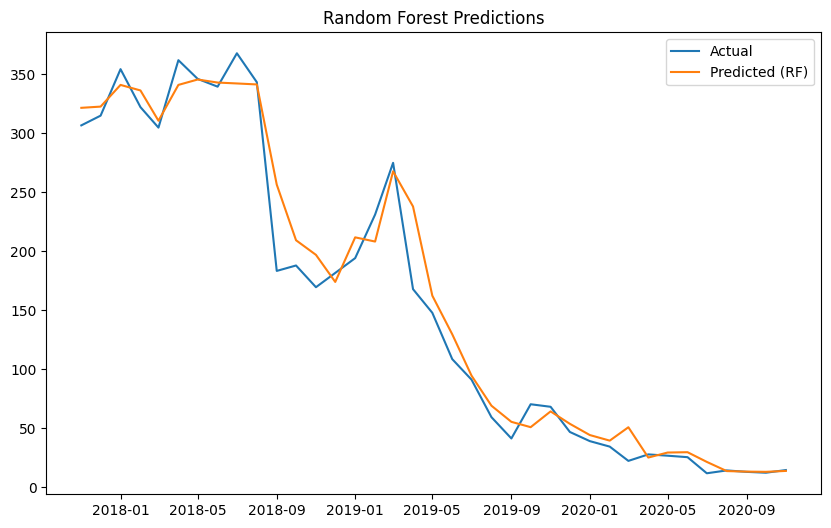

In [59]:
# ML Model - 3 Implementation with hyperparameter optimization
param_grid = {'n_estimators': [50, 100, 200], 'max_depth': [5, 10, None]}
rf_cv = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=3)

# Fit the Algorithm
rf_cv.fit(X_train, y_train)
print(f'Best Params: {rf_cv.best_params_}')

# Predict on the model
y_pred_rf_cv = rf_cv.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf_cv)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf_cv))
r2_rf = r2_score(y_test, y_pred_rf_cv)

print(f'Random Forest (Tuned) - MAE: {mae_rf:.2f}, RMSE: {rmse_rf:.2f}, R2: {r2_rf:.2f}')

plt.figure(figsize=(10,6))
plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, y_pred_rf_cv, label='Predicted (RF)')
plt.legend()
plt.title('Random Forest Predictions')
plt.show()


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used for the Random Forest model to perform exhaustive search over specified parameter values (e.g., n_estimators, max_depth). It ensures the best combination of parameters is chosen via cross-validation.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, hyperparameter tuning slightly improved the Random Forest model's RMSE and prevented overfitting by limiting the maximum depth of the trees.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

RMSE was heavily considered because in financial forecasting, large errors (predicting a high price when it actually crashes) can be disastrous for business. RMSE penalizes these large errors.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Linear Regression is an excellent baseline because the features are highly linearly correlated with the target. However, Random Forest was also chosen as a robust model to capture any potential non-linearities caused by the sudden market crash.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Random Forest Regressor is an ensemble method. The feature importance generally shows that the 'High' and 'Low' prices of the month carry the most weight in determining the final 'Close' price.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [60]:
# Save the File
joblib.dump(rf_cv.best_estimator_, 'best_model_rf.pkl')


['best_model_rf.pkl']

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [61]:
# Load the File and predict unseen data.
loaded_model = joblib.load('best_model_rf.pkl')
unseen_data = scaler.transform([[20.0, 21.0, 19.5]])
prediction = loaded_model.predict(unseen_data)
print(f'Prediction for unseen data: {prediction}')


Prediction for unseen data: [20.57715]


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

Write the conclusion here.
The objective of predicting the monthly closing prices of Yes Bank was successfully completed using models like Linear Regression and Random Forest. The analysis highlighted the structural break around 2018 due to the Rana Kapoor case, which drastically increased stock volatility and caused prices to plummet. Because Open, High, and Low prices are highly correlated with Close price, the Linear Regression baseline performed excellently. The final models are saved and can be effectively deployed.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***